надо рисовать раастояния до k-го соседа и смотреть как они изменяются при переходе от random background -> b27+ background

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
b27pos = pd.read_parquet('knees/kneighbors_b27pos.parquet')

In [3]:
small = pd.read_parquet('knees/kneighbors_small.parquet')

In [4]:
small

,n_0,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,n_9,...,n_40,n_41,n_42,n_43,n_44,n_45,n_46,n_47,n_48,n_49
0,0.000000,0.078032,10.116940,10.222188,11.394521,12.790281,12.790281,14.281559,14.994667,16.067980,...,22.408356,22.448839,22.448839,22.496412,22.557089,22.575642,22.580919,22.769650,22.833431,22.947405
1,0.000004,9.018757,10.459798,10.542737,10.542737,12.984821,13.516729,13.616888,13.673408,13.955599,...,18.166819,18.327797,18.347816,18.380495,18.380495,18.482904,18.614801,18.633677,18.669752,18.716381
2,0.000001,7.717223,15.308578,16.310768,17.030228,18.268459,18.803082,19.135578,19.565279,19.985321,...,26.474113,26.524286,26.582245,26.680729,26.687143,26.791870,26.791870,26.860796,27.074986,27.189043
3,0.000002,14.333114,21.910089,24.652092,25.609219,26.597347,26.707186,27.107414,27.857071,28.646994,...,33.117897,33.210945,33.287849,33.292637,33.296299,33.301586,33.333725,33.398232,33.509254,33.560474
4,0.000003,8.531192,10.149387,10.614073,11.043463,11.374178,11.887232,11.887232,12.315060,12.317032,...,18.170555,18.171217,18.198481,18.415457,18.478865,18.511839,18.511839,18.793999,18.843515,18.873791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169754,0.000000,3.529382,11.114272,12.417246,12.987082,14.518231,15.141300,15.316425,15.460360,16.057076,...,19.001825,19.351807,19.428596,19.624701,19.642475,19.841051,20.002554,20.079659,20.104723,20.417339
1169755,0.000000,3.529382,11.094726,12.085776,12.283974,12.557010,13.149056,14.931034,15.104265,15.266337,...,18.382124,18.382124,18.407785,18.522936,18.753016,18.764452,18.910551,18.932680,18.982761,19.003397
1169756,0.000002,0.000002,15.290200,17.077005,19.579237,19.644516,21.648932,21.858551,21.960791,22.318338,...,31.979181,32.025219,32.025936,32.275459,32.453133,32.754894,32.873646,33.170853,33.252956,33.398018
1169757,0.000003,12.670113,15.987489,17.791901,18.573576,18.813551,18.849844,19.066401,19.348562,19.718935,...,23.653404,23.718643,23.887999,24.265079,24.299921,24.368771,24.479591,24.483303,24.561703,24.655502


In [5]:
b27pos

,n_0,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,n_9,...,n_40,n_41,n_42,n_43,n_44,n_45,n_46,n_47,n_48,n_49
0,0.000002,0.148580,10.071576,10.151918,11.334796,12.783799,12.783799,14.229167,14.946488,15.989724,...,22.424988,22.437916,22.466789,22.478073,22.478073,22.503185,22.655092,22.708624,22.851084,22.969410
1,0.000003,8.928626,10.336414,10.449706,10.449706,13.020452,13.472896,13.531416,13.628610,14.069922,...,18.178310,18.335588,18.373438,18.412388,18.412388,18.464193,18.560085,18.639730,18.643473,18.668795
2,0.000000,7.558357,15.229172,15.892221,16.498573,17.885405,18.697933,18.746984,19.201101,19.354923,...,26.116100,26.240986,26.268515,26.330976,26.581598,26.606539,26.654730,26.689600,26.689600,26.867464
3,0.000000,14.315600,21.887827,24.567715,25.595507,26.553219,26.722319,27.063957,27.823675,28.571014,...,32.995533,33.036934,33.122322,33.221458,33.247753,33.289501,33.320515,33.331005,33.364201,33.451279
4,0.000003,8.508057,10.116570,10.608948,10.999925,11.332650,11.788944,11.788944,12.248720,12.278841,...,18.098265,18.168783,18.238390,18.394190,18.432402,18.473125,18.473125,18.761374,18.766455,18.859188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169754,0.000001,3.531800,11.081409,12.419947,13.031960,14.507175,15.152360,15.345668,15.376335,16.118319,...,19.106640,19.334974,19.394817,19.561314,19.592743,19.851244,19.961937,20.041159,20.087803,20.350492
1169755,0.000002,3.531800,11.094602,12.076216,12.259255,12.570167,13.198380,14.928720,15.024195,15.330179,...,18.360901,18.360901,18.372576,18.564083,18.676529,18.807405,18.871845,18.937307,18.994339,19.113115
1169756,0.000002,0.000002,15.380829,16.975798,19.558765,19.662365,21.494934,21.774624,21.974274,22.315060,...,31.989344,32.023357,32.050175,32.061111,32.282505,32.586861,32.837708,33.148594,33.234116,33.396294
1169757,0.000002,12.553409,15.829360,17.487345,18.571892,18.746788,18.870251,18.927275,19.245226,19.665401,...,23.585541,23.747971,23.892958,24.198263,24.249746,24.250771,24.397375,24.465118,24.627447,24.677017


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


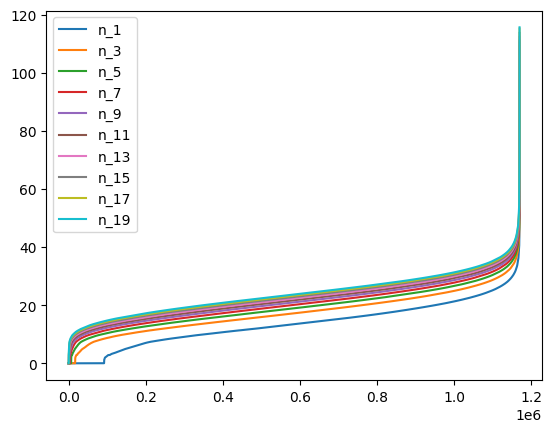

In [6]:
for i in range(1, 20, 2):
    col = f'n_{i}'
    sns.lineplot(sorted(b27pos[col]), label=col)

# plt.xlim(0, 700000)
# plt.ylim(0, 20)
plt.legend()

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


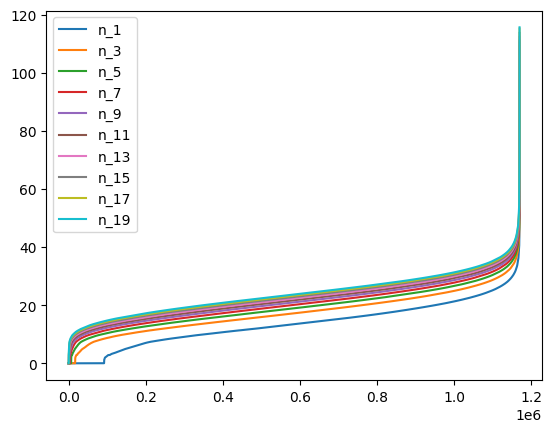

In [7]:
for i in range(1, 20, 2):
    col = f'n_{i}'
    sns.lineplot(sorted(b27pos[col]), label=col)

# plt.xlim(0, 700000)
# plt.ylim(0, 20)
plt.legend()

<Axes: >

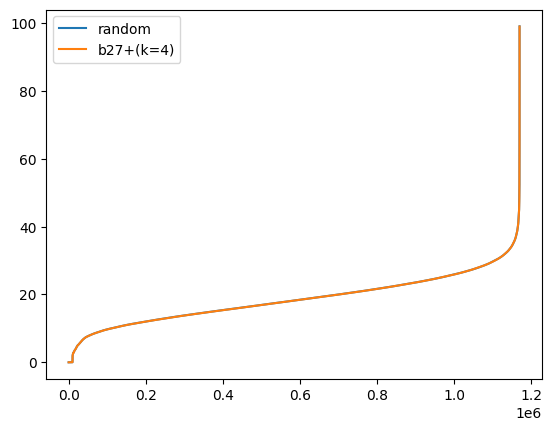

In [8]:
# sns.lineplot(sorted(b27pos['n_8']), label='b27+(k=8)')
sns.lineplot(sorted(small['n_4']), label='random')
sns.lineplot(sorted(b27pos['n_4']), label='b27+(k=4)')



In [9]:
small['n_4']

0          11.394521
1          10.542737
2          17.030228
3          25.609219
4          11.043463
             ...    
1169754    12.987082
1169755    12.283974
1169756    19.579237
1169757    18.573576
1169758    15.889939
Name: n_4, Length: 1169759, dtype: float64

разнообразие + размер выборки

мерить энтропию кластера?
сделать некотрую метрику гранулярности

сравнить резкость графика с vdjdb?


по бехтереву проверить что будет если брать только тех кого вообще нет в положительных

In [10]:
y = sorted(b27pos.n_4)
y = sorted([i for i, j in zip(y, y[1:]) if i != j])[:200000]

In [11]:
x = [i for i in range(len(y))]#[25000:]

In [12]:
len(y)

200000

Точка колена: 37094 8.785971641540527


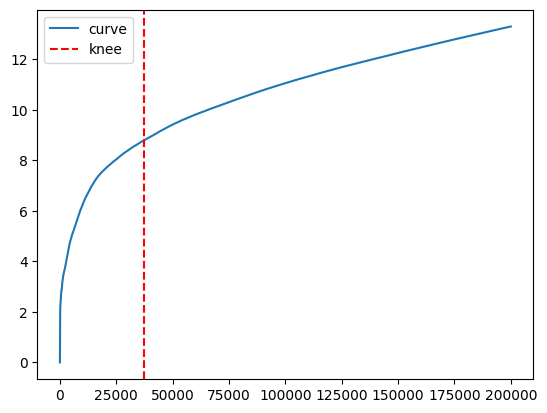

In [13]:
from kneed import KneeLocator


knee = KneeLocator(x,  # x values
                   y,  # y values
                   S=1,  # parameter suggested from paper
                   curve="concave",
                   interp_method="polynomial",
                   polynomial_degree=10,
                   online=True,
                   direction="increasing", )
print("Точка колена:", knee.knee, y[knee.knee])

# Визуализация
plt.plot(x, y, label='curve')
plt.axvline(knee.knee, color='red', linestyle='--', label='knee')
plt.legend()
plt.show()


<Axes: >

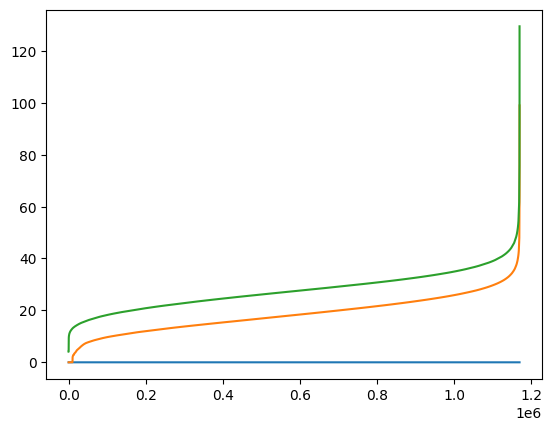

In [32]:
sns.lineplot(sorted(b27pos.n_0))
sns.lineplot(sorted(b27pos.n_4))
sns.lineplot(sorted(b27pos.n_49))

Точка колена: 399 8.870721817016602


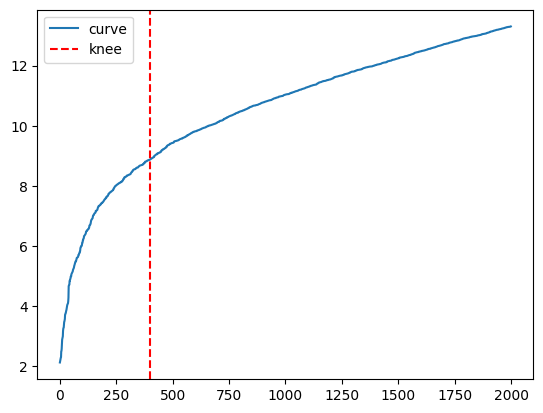

In [25]:
y = sorted(b27pos.n_4)
y = sorted(pd.Series(sorted([i for i, j in zip(y, y[1:]) if i != j])[:200000]).sample(2000))
x = [i for i in range(len(y))]

knee = KneeLocator(x,  # x values
                   y,  # y values
                   S=1,  # parameter suggested from paper
                   curve="concave",
                   interp_method="polynomial",
                   polynomial_degree=10,
                   online=True,
                   direction="increasing", )
print("Точка колена:", knee.knee, y[knee.knee])

# Визуализация
plt.plot(x, y, label='curve')
plt.axvline(knee.knee, color='red', linestyle='--', label='knee')
plt.legend()
plt.show()

In [ ]:
from scipy.interpolate import UnivariateSpline

spline = UnivariateSpline(x, y, s=1e7)  # параметр s — сглаживание (подбери вручную)
y_smooth = spline(x)

In [10]:
# Первая производная
dy = np.gradient(y, x)

# Вторая производная
ddy = np.gradient(dy, x)

# Ищем максимум модуля второй производной
i_max = np.argmax(np.abs(ddy))
x_max = x[i_max]

In [12]:
sorted_indices = np.argsort(ddy)[::-1]
sorted_indices

array([1052341, 1052342, 1052340, ..., 1052336,       5,       4])

In [27]:
y[100]

4.7826738357543945

In [13]:
sorted_indices[:20]

array([1052341, 1052342, 1052340, 1052334,       3,       2, 1052338,
       1052339, 1052321, 1052320, 1052325, 1052335, 1052329, 1052333,
       1052324, 1052311, 1052310, 1052297, 1052301, 1052314])

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# --- Функция нахождения колена ---
def find_elbow_univariate_spline(x, y, scale=1.0, plot=True):
    # Сортируем, если x не отсортирован
    sort_idx = np.argsort(x)
    x, y = x[sort_idx], y[sort_idx]

    # Автоматический подбор сглаживания
    s = 0.1
    spline = UnivariateSpline(x, y, s=s)
    y_smooth = spline(x)

    # Первая и вторая производные
    dy = spline.derivative(n=1)(x)
    ddy = spline.derivative(n=2)(x)

    # Кривизна
    curvature = np.abs(ddy) / (1 + dy**2)**1.5
    print(ddy)
    x_knee = x[np.argmax(ddy)]
    print(x_knee)

    # Визуализация
    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(x, y, color='lightgray', label='Исходные данные')
        plt.plot(x, y_smooth, color='blue', label='Сглаженные данные')
        # plt.plot(x, dy, color='red', label='Производная')
        # plt.plot(x, ddy, color='green', label='Вторая произв')
        plt.axvline(x_knee, color='red', linestyle='--', label=f'Колено: x={x_knee:.2f}')
        plt.legend()
        plt.title('Поиск точки колена через UnivariateSpline')
        plt.xlabel('x')
        plt.ylabel('y')
        # plt.xlim(0, 1000)
        plt.tight_layout()
        plt.show()

    return x_knee

# --- Пример использования ---
# x = np.linspace(0, 10, 1000000)
# y = np.log(x + 1) + np.random.normal(0, 0.05, size=x.shape)
# x_knee = find_elbow_univariate_spline(x, y, scale=1.0)


In [53]:
x = np.array(x)
x

array([      0,       1,       2, ..., 1052340, 1052341, 1052342])

In [54]:
y = np.array(y)
y

array([0.00000000e+00, 1.34869913e-06, 1.90734863e-06, ...,
       9.91362534e+01, 1.03839294e+02, 1.14462502e+02])

[ 1.28555167 -0.01225787 -1.3100674  ...  7.14115456  5.94403122
  4.74690787]
1052338


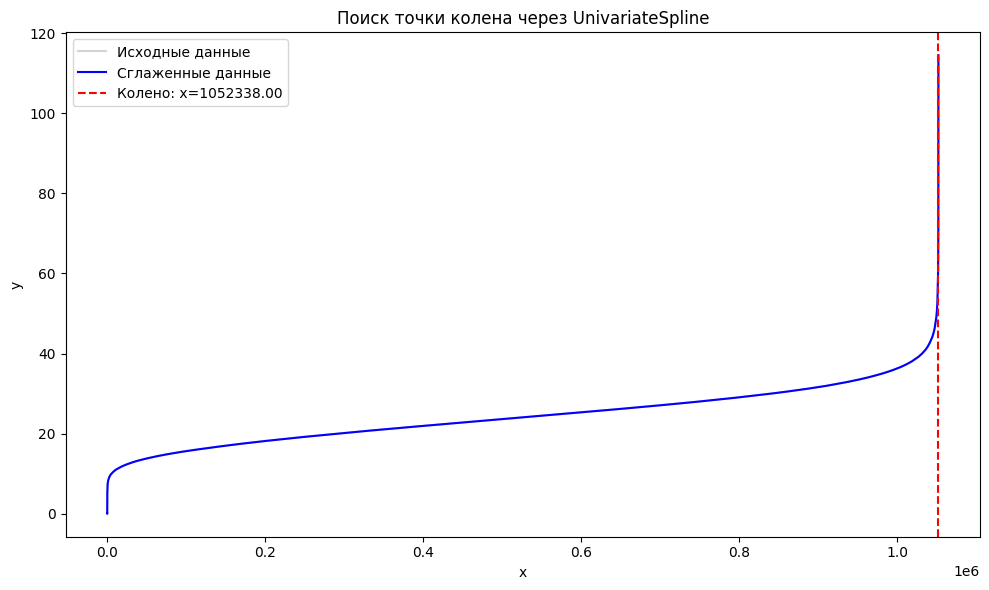

In [55]:
x_knee = find_elbow_univariate_spline(x, y, scale=1.0)
